✅ Train shape: (212, 6)
✅ Test shape: (54, 6)

📌 Model: XGBoost
🔹 Accuracy: 96.3%
🔹 Predicted Room for custom input: Room 2


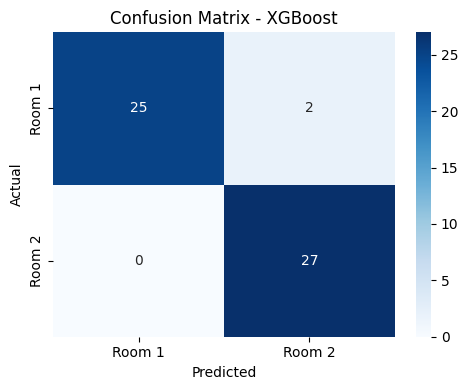


📌 Model: Random Forest
🔹 Accuracy: 96.3%
🔹 Predicted Room for custom input: Room 2


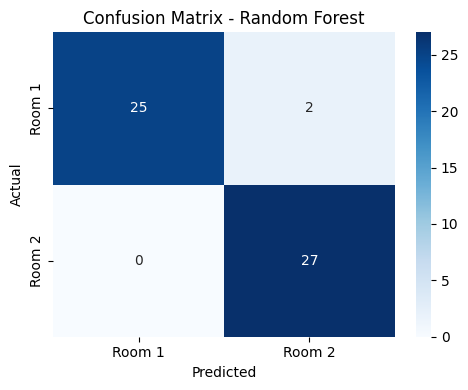


📌 Model: K-Nearest Neighbors
🔹 Accuracy: 98.15%
🔹 Predicted Room for custom input: Room 2


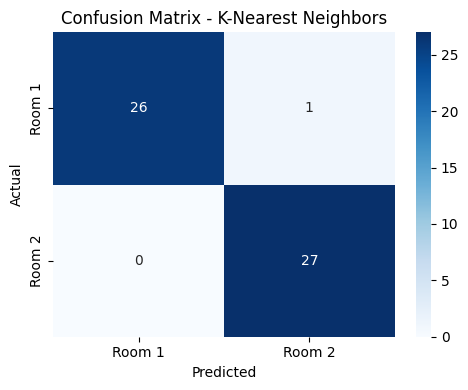


📌 Model: Multilayer Perceptron
🔹 Accuracy: 98.15%
🔹 Predicted Room for custom input: Room 2


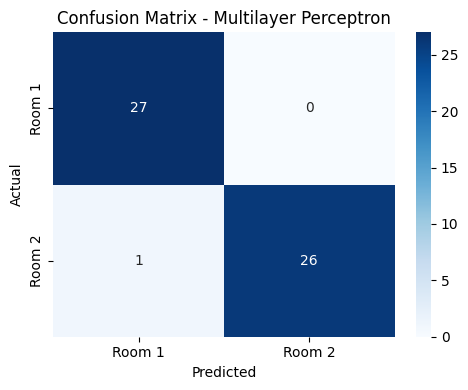

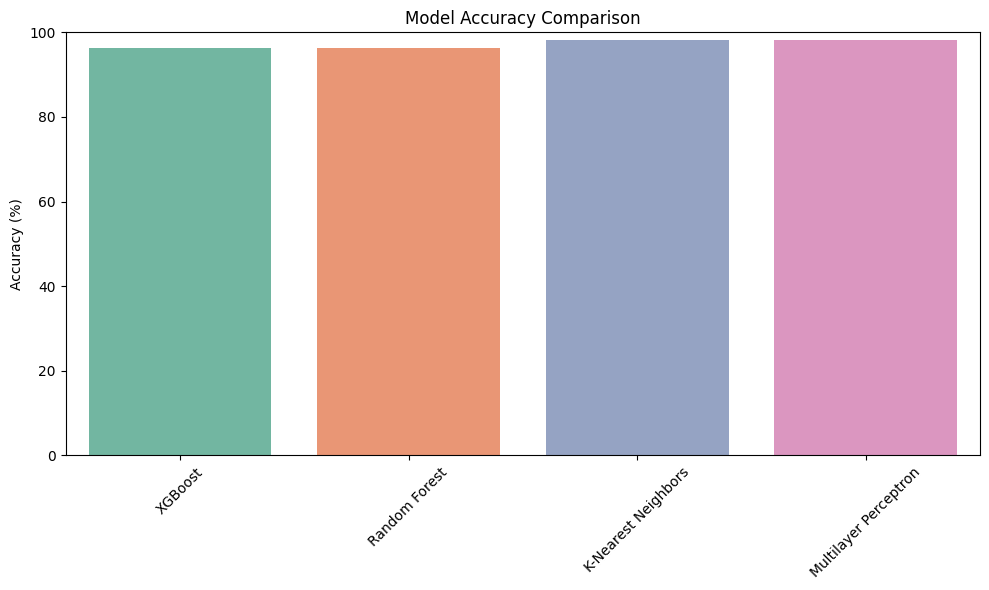


✅ XGBoost model saved as 'rssi_room_model.pkl'


In [1]:
import pandas as pd
import numpy as np
import warnings
import joblib
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import accuracy_score, confusion_matrix
from sklearn.ensemble import RandomForestClassifier
from sklearn.neighbors import KNeighborsClassifier
from sklearn.svm import SVC
from sklearn.neural_network import MLPClassifier
import xgboost as xgb

# Suppress warnings
warnings.filterwarnings("ignore")

# --- Load and Prepare Dataset ---

# Load CSV files
room1_df = pd.read_csv("room1.csv")
room2_df = pd.read_csv("room2.csv")

# Add room labels
room1_df['Room'] = 'Room 1'
room2_df['Room'] = 'Room 2'

# Combine datasets
df = pd.concat([room1_df, room2_df], ignore_index=True)

# Encode room labels (0 for Room 1, 1 for Room 2)
df['Room_Label'] = df['Room'].map({'Room 1': 0, 'Room 2': 1})

# Columns with RSSI values
beacon_cols = ['Beacon1', 'Beacon2', 'Beacon3', 'Beacon4', 'Beacon5', 'Beacon6']

# Identify the nearest beacon (max RSSI value)
df['Nearest_Beacon'] = df[beacon_cols].idxmax(axis=1)

# Optional: Encode Nearest_Beacon for feature use
label_encoder = LabelEncoder()
df['Nearest_Beacon_Label'] = label_encoder.fit_transform(df['Nearest_Beacon'])

# Define features and target
X = df[beacon_cols]  # You can add 'Nearest_Beacon_Label' if desired
y = df['Room_Label']

# Split into train/test sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

print("✅ Train shape:", X_train.shape)
print("✅ Test shape:", X_test.shape)

# --- Model Training & Evaluation ---

# Define models
models = {
    "XGBoost": xgb.XGBClassifier(use_label_encoder=False, eval_metric='mlogloss'),
    "Random Forest": RandomForestClassifier(n_estimators=100, random_state=42),
    "K-Nearest Neighbors": KNeighborsClassifier(n_neighbors=3),
    "Multilayer Perceptron": MLPClassifier(hidden_layer_sizes=(100,), max_iter=300, random_state=42)
}

# Custom input sample
custom_input = np.array([[-88, -95, -98, -88, -91, -75]])

# Track accuracy for plotting
model_accuracies = {}

# Train, evaluate and visualize
for name, model in models.items():
    model.fit(X_train, y_train)
    y_pred = model.predict(X_test)
    acc = accuracy_score(y_test, y_pred)
    model_accuracies[name] = acc * 100

    predicted_room = model.predict(custom_input)[0]
    room_label = 'Room 1' if predicted_room == 0 else 'Room 2'

    print(f"\n📌 Model: {name}")
    print(f"🔹 Accuracy: {round(acc * 100, 2)}%")
    print(f"🔹 Predicted Room for custom input: {room_label}")

    # Plot confusion matrix
    cm = confusion_matrix(y_test, y_pred)
    plt.figure(figsize=(5, 4))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=['Room 1', 'Room 2'], yticklabels=['Room 1', 'Room 2'])
    plt.title(f"Confusion Matrix - {name}")
    plt.xlabel('Predicted')
    plt.ylabel('Actual')
    plt.tight_layout()
    plt.show()

# --- Accuracy Comparison Plot ---
plt.figure(figsize=(10, 6))
sns.barplot(x=list(model_accuracies.keys()), y=list(model_accuracies.values()), palette='Set2')
plt.ylabel("Accuracy (%)")
plt.title("Model Accuracy Comparison")
plt.xticks(rotation=45)
plt.ylim(0, 100)
plt.tight_layout()
plt.show()

# --- Save only the XGBoost model ---
best_model = models["XGBoost"]
joblib.dump(best_model, 'rssi_room_model.pkl')
print("\n✅ XGBoost model saved as 'rssi_room_model.pkl'")
